In [32]:
#%pip install -U azure-common azure-core azure-identity azure-mgmt-core SQLAlchemy==2.0.30 pandas faiss-cpu PyJWT==2.8.0 pyodbc==5.1.0 
#tabulate==0.9.0 tiktoken==0.6.0 urllib3==1.26.1
#!pip install seaborn plotly matplotlib

In [33]:
#%%capture --no-stderr
#%pip install -U langgraph langchain-openai

In [ ]:
import getpass
import os
from langchain_openai import AzureChatOpenAI
from typing import Literal
from langchain_core.tools import tool
from dotenv import load_dotenv
load_dotenv()
model = AzureChatOpenAI()

In [2]:
from sqlalchemy import create_engine, event, text
from azure.identity import DefaultAzureCredential
import struct
import sys
from langchain.sql_database import SQLDatabase

class DatabaseManager:
    def __init__(self):
        self.azure_credentials = DefaultAzureCredential()
        self.engine = create_engine("mssql+pyodbc://" + os.environ["SQL_SERVER_NAME"] + "/" + os.environ["SQL_SERVER_DATABASE"] + "?driver=ODBC+Driver+18+for+SQL+Server")
        self.SQL_COPT_SS_ACCESS_TOKEN = 1256
        self.TOKEN_URL = "https://database.windows.net/.default"
        self.FABRIC_SCOPE = "https://fabric.microsoft.com/.default"
        self.setup_event_listener()
        

    def setup_event_listener(self):
        @event.listens_for(self.engine, "do_connect")
        def provide_token(dialect, conn_rec, cargs, cparams):
            cargs[0] = cargs[0].replace(";Trusted_Connection=Yes", "")
            raw_token = self.azure_credentials.get_token(
                self.TOKEN_URL, scopes=[self.FABRIC_SCOPE]
            ).token.encode("utf-16-le")
            token_struct = struct.pack(
                f"<I{len(raw_token)}s", len(raw_token), raw_token
            )
            cparams["attrs_before"] = {self.SQL_COPT_SS_ACCESS_TOKEN: token_struct}

    def connect_to_database(self):
        try:
            with self.engine.connect() as conn:
                result = conn.execute(text("SELECT @@VERSION"))
                version = result.fetchone()
                print("Connection successful!")
                print(version)
                db = SQLDatabase(self.engine, view_support=True, schema="dbo")
                #print("Found following tables:", db.get_usable_table_names())
                return db
        except Exception as e:
            print(e)
            sys.exit(1)


In [3]:
from langchain_community.vectorstores import FAISS
from langchain_core.example_selectors import SemanticSimilarityExampleSelector
from langchain_openai.embeddings.azure import AzureOpenAIEmbeddings
from langchain_core.prompts import (
    ChatPromptTemplate,
    FewShotPromptTemplate,
    MessagesPlaceholder,
    PromptTemplate,
    SystemMessagePromptTemplate,
)

class Prompt:
    def __init__(self, input):
        
        self.input = input
        
        self.systemprompt = """
        You are an agent designed to interact with a mssql database.
        Always Format the response in Output as Json
        Given an input question, create a syntactically correct sql query to run, then look at the results of the query and return the answer.
        Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most 500 results.
        You can order the results by a relevant column to return the most interesting examples in the database.
        Never query for all the columns from a specific table, only ask for the relevant columns given the question.
        You have access to tools for interacting with the database.
        Only use the given tools. Only use the information returned by the tools to construct your final answer.
        You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.

        DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.

        If the question does not seem related to the database, just return "I don't know" as the answer.

        Here are some examples of user inputs and their corresponding SQL queries:

        Use the "loansfinal" view. Donot perform joins between table and a view to answer the query. All the information will be present in the view

        Facts you need to know:
            - There is NO 'llm_chain' attribute - never reference it as a database column
            - If you cannot interpret the column name don't use it in the query

        Rules:
            - Always Format the Output as Json, Retain the Column Names as they are in the Database
            - LIMIT the number of outputs of agent to 500 rows
        """

        self.queryexamples = [
            {
                "input": "Compute Average Credit Score by home ownership type",
                "query": "SELECT HomeOwnshp, AVG(CAST(CrdtScore AS INT)) AS AvgCreditScore FROM loansfinal GROUP BY HomeOwnshp",
            },
            {
                "input": "Produce a table listing Average credit score, Average Annual Income of applicants by their employment experience.",
                "query": "SELECT YearsJob, AVG(CAST(AnnlIncome AS FLOAT)) AS AvgAnnualIncome FROM loansfinal GROUP BY YearsJob",
            },
        ]

        self.system_prefix = self.systemprompt
        self.examples = self.queryexamples
        '''
        example_selector: An instance of SemanticSimilarityExampleSelector that selects examples based on semantic similarity.
        '''
        self.example_selector = SemanticSimilarityExampleSelector.from_examples(
            self.examples,
            AzureOpenAIEmbeddings(model="text-embedding-3-large"),
            FAISS,
            k=5,
            input_keys=["input"],
        )

        '''
        few_shot_prompt: A FewShotPromptTemplate instance that generates a prompt for few-shot learning.
        '''
        self.few_shot_prompt = FewShotPromptTemplate(
            example_selector=self.example_selector,
            example_prompt=PromptTemplate.from_template(
                "User input: {input}\nSQL query: {query}"
            ),
            input_variables=["input", "mssql", "100"],
            prefix=self.system_prefix,
            suffix="",
        )
    
        '''
        An instance of ChatPromptTemplate that constructs the full prompt from a series of messages.
        '''
        self.full_prompt = ChatPromptTemplate.from_messages(
            [
                SystemMessagePromptTemplate(prompt=self.few_shot_prompt),
                ("human", "{input}"),
                MessagesPlaceholder("agent_scratchpad"),
            ]
        )

    def get_full_prompt(self):
        finalprompt = self.full_prompt.invoke(
            {
                "input": self.input,
                "top_k": 1,
                "dialect": "MSSQL",
                "agent_scratchpad": [],
            }
        )
        return finalprompt


In [4]:
prompt = "What is the average credit score by home ownership type?"
full_prompt = Prompt(prompt).get_full_prompt()

In [5]:
def make_system_prompt(suffix: str) -> str:
    """Generate a system prompt for the AI assistant.
    
    Args:
        suffix (str): Additional context or instructions to append to the base system prompt.
    
    Returns:
        str: The complete system prompt.
    """
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{suffix}"
    )

In [6]:
from typing import Annotated
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

repl = PythonREPL()

@tool
def python_repl_tool(code: Annotated[str, "The python code to execute to generate your chart."]):
    """Execute Python code using a Python REPL (Read-Eval-Print Loop).
    
    Args:
        code (str): The Python code to execute.
    
    Returns:
        str: The result of the executed code or an error message if execution fails.
    """
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )


In [7]:
from langchain_community.agent_toolkits.sql.base import create_sql_agent
from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit
import pandas as pd
import json

@tool
def fetch_relational_data(full_prompt):
    """Run Langchain SQL Agent Executor to fetch relational data from a database based on a prompt.
    
    Args:
        code (str): The prompt to generate the SQL query.
    
    Returns:
        JSON : The JSON data from the database.
    """
    try:
        db_manager = DatabaseManager()
        db = db_manager.connect_to_database()
        agent_executor = create_sql_agent(
            llm=model,
            toolkit=SQLDatabaseToolkit(db=db, llm=model),
            verbose=True,
            agent_type="openai-tools",
            agent_executor_kwargs={"return_intermediate_steps": True},
        )
        response = agent_executor.invoke({"input": full_prompt})

        response_text = response.get("output", "")
        print("Response Text ##########", response_text)
        json_start = response_text.find("```json\n") + len("```json\n")
        json_end = response_text.find("\n```", json_start)
        json_data = response_text[json_start:json_end]
        parsed_data = json.loads(json_data)
        #print("Data Parsed ##########", parsed_data)
        #keys = list(parsed_data[0].keys())
        #print("Keys ##########", keys)
        #values = [list(item.values()) for item in parsed_data]
        #print("Values ##########", values)
        #data = pd.DataFrame(values, columns=keys)   
        return parsed_data
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return (
        parsed_data
    )




In [8]:
def make_sql_prompt(suffix: str) -> str:
    """Generate a system prompt for the AI assistant.
    
    Args:
        suffix (str): Additional context or instructions to append to the base system prompt.
    
    Returns:
        str: The complete system prompt.
    """
    return (
        """ 
        You are a helpful AI assistant, collaborating with other assistants."
        
        You are an agent designed to interact with a mssql database.
        Always Format the response in Output as Json
        Given an input question, create a syntactically correct sql query to run, then look at the results of the query and return the answer.
        Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most 500 results.
        You can order the results by a relevant column to return the most interesting examples in the database.
        Never query for all the columns from a specific table, only ask for the relevant columns given the question.
        You have access to tools for interacting with the database.
        Only use the given tools. Only use the information returned by the tools to construct your final answer.
        You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.

        DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.

        If the question does not seem related to the database, just return "I don't know" as the answer.

        Here are some examples of user inputs and their corresponding SQL queries:

        Use the "loansfinal" view. Donot perform joins between table and a view to answer the query. All the information will be present in the view

        Facts you need to know:
            - There is NO 'llm_chain' attribute - never reference it as a database column
            - If you cannot interpret the column name don't use it in the query

        Rules:
            - Always Format the Output as Json, Retain the Column Names as they are in the Database
            - LIMIT the number of outputs of agent to 500 rows
            - Do not make multiple connections. Once you get the answer return the result or pass on to the next node
        """
        f"\n{suffix}"
    )

In [9]:
from typing import Literal
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState, END
from langgraph.types import Command

prompt = "Donot run query multiple times for the same question. Once you get the answer return the result or pass on to the next node"
full_prompt = Prompt(prompt).get_full_prompt()
sql_agent = create_react_agent(model, [fetch_relational_data], state_modifier=make_sql_prompt(prompt))

In [10]:
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

In [44]:
#inputs = {"messages": [("user", "What is the average credit score by loan purpose?")]}

#print_stream(sql_agent.stream(inputs, stream_mode="values"))

In [11]:

def sql_node(state: MessagesState) -> Command[Literal["chart_node", END]]:
    """Execute the sql agent node, which fetches the data from Fabric using the fetch_relational_data tool.
    
    Args:
        state (MessagesState): The current state of the conversation.
    
    Returns:
        Command: A command object containing the updated state and the next node to transition to.
    """
    result = sql_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "chart_node")
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="sql_node"
    )
    return Command(update={"messages": result["messages"]}, goto=goto)

chart_task = """Create clear and visually appealing charts using seaborn and plotly. Follow these rules:
1. Add a title, labeled axes (with units), and a legend if needed.
2. Use `sns.set_context("notebook")` for readable text and themes like `sns.set_theme()` or `sns.set_style("whitegrid")`.
3. Use accessible color palettes like `sns.color_palette("husl")`.
4. Choose appropriate plots: `sns.lineplot()`, `sns.barplot()`, or `sns.heatmap()`.
5. Annotate key points (e.g., "Peak in 2020") for clarity.
6. Ensure the chart's width and display resolution is no wider than 1000px.
7. Display with `plt.show()`.
Goal: Produce accurate, engaging, and easy-to-interpret charts."""

chart_agent = create_react_agent(model, [python_repl_tool], state_modifier=make_system_prompt(chart_task))

def get_next_node(last_message: BaseMessage, goto: str):
    """Determine the next node to transition to based on the last message.
    
    Args:
        last_message (BaseMessage): The last message in the conversation.
        goto (str): The default node to transition to if no final answer is found.
    
    Returns:
        str: The next node to transition to, or END if a final answer is found.
    """
    if "FINAL ANSWER" in last_message.content:
        return END
    return goto

def chart_node(state: MessagesState) -> Command[Literal[END]]:
    """Execute the chart node, which generates charts using the Python REPL tool.
    
    Args:
        state (MessagesState): The current state of the conversation.
    
    Returns:
        Command: A command object containing the updated state and the next node to transition to.
    """
    result = chart_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "sql_node")
    #goto = 'END'
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="chart_node"
    )
    return Command(update={"messages": result["messages"]}, goto=goto)

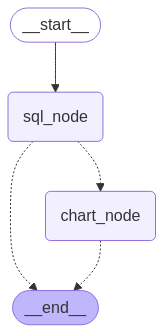

In [12]:
from langgraph.graph import StateGraph, START
from IPython.display import Image, display

workflow = StateGraph(MessagesState)
workflow.add_node("sql_node", sql_node)
workflow.add_node("chart_node", chart_node)
workflow.add_edge(START, "sql_node")
#workflow.add_edge("sql_node", "chart_node")
#workflow.add_edge("chart_node", END)

graph = workflow.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [13]:
def print_pretty(event):
    """Pretty-print the event messages for debugging or logging purposes.
    
    Args:
        event (dict): The event containing messages from the research or chart node.
    """
    # Check if the event contains 'research_node' or 'chart_node'
    for node_key in ["chart_node"]:
        if node_key in event:
            messages = event[node_key].get("messages", [])
            print(f"{node_key}: [")
            for message in messages:
                # Extract message type (HumanMessage, AIMessage, etc.)
                message_type = message.__class__.__name__

                # Extract message content
                content = message.content
                if isinstance(content, list):
                    content = [item for item in content]  # Handle list content (e.g., AIMessage with tool use)
                elif isinstance(content, str):
                    content = f'"{content}"'  # Wrap string content in quotes

                additional_kwargs = message.additional_kwargs
                response_metadata = message.response_metadata
                message_id = message.id

                # Print the message in the desired format
                print(f"    {message_type}(")
                print(f"        content={content},")
                print(f"        additional_kwargs={additional_kwargs},")
                print(f"        response_metadata={response_metadata},")
                print(f"        id='{message_id}'")
                print( "    ),")
            print("]")
            print("-" * 120)
            return

    print("No messages found in the event.")                # Extract additional fields

Connection successful!
('Microsoft Azure SQL Data Warehouse (RTM) - 12.0.2000.8 \n\tMar  5 2025 11:26:03 \n\tCopyright (C) 2024 Microsoft Corporation\n',)


> Entering new SQL Agent Executor chain...

Invoking: `sql_db_list_tables` with `{}`


Loans, loansclean, loansfinal
Invoking: `sql_db_schema` with `{'table_names': 'loansfinal'}`



CREATE TABLE dbo.loansfinal (
	[LoanID] VARCHAR(8000) COLLATE Latin1_General_100_BIN2_UTF8 NULL, 
	[CustomerID] VARCHAR(8000) COLLATE Latin1_General_100_BIN2_UTF8 NULL, 
	[Status] VARCHAR(8000) COLLATE Latin1_General_100_BIN2_UTF8 NULL, 
	[Amount] VARCHAR(8000) COLLATE Latin1_General_100_BIN2_UTF8 NULL, 
	[Term] VARCHAR(8000) COLLATE Latin1_General_100_BIN2_UTF8 NULL, 
	[CreditScore] INTEGER NULL, 
	[YearsJob] VARCHAR(8000) COLLATE Latin1_General_100_BIN2_UTF8 NULL, 
	[HomeOwnshp] VARCHAR(8000) COLLATE Latin1_General_100_BIN2_UTF8 NULL, 
	[AnnualIncome] INTEGER NULL, 
	[Purpose] VARCHAR(8000) COLLATE Latin1_General_100_BIN2_UTF8 NULL, 
	[MthlyDebt] VAR

Python REPL can execute arbitrary code. Use with caution.
Python REPL can execute arbitrary code. Use with caution.
<string>:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<string>:20: UserWarning:

The palette list has more values (6) than needed (3), which may not be intended.



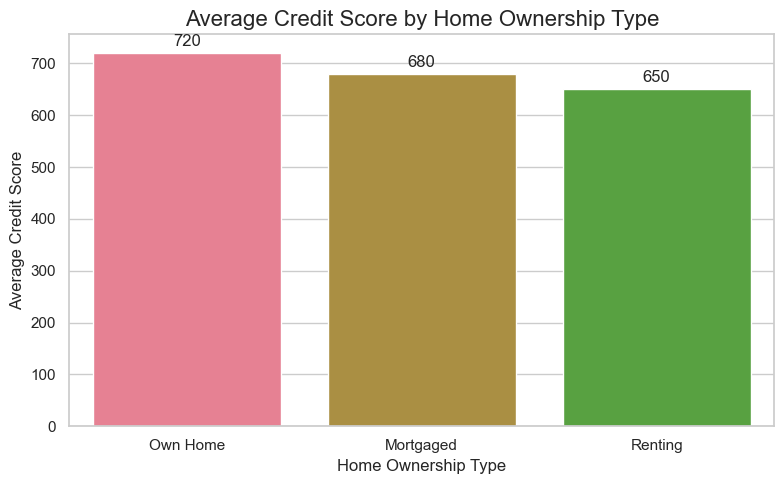

In [14]:
events = graph.stream(
    {
        "messages": [
            HumanMessage(
                content= ''' Plot the Average credit score against the Home ownership type. the plot should have a title, labeled axes, and a legend. Use seaborn and plotly to create the chart.
Once you make the appropirate chart that you think is correct, finish.
Make sure to adhere to the data u get from the sql node agent
'''
               #"First, get the USA's population data for the past 50 years. "
               # "Then, create a line chart with annotations for significant events like economic recessions. "
            #"Add a trendline using numpy.polyfit. "
                #"Once you make the chart, finish."
            )
        ],
    },
    {"recursion_limit": 20},
)

# Print events using print_pretty
for event in events:
    print_pretty(event)